# Objetivo do trabalho
Uso do Quantum circuit para detecção de cancer de intestino
- Dateset: NCTCRHE100K
- 5000 imagens de não cancer
- 5000 imagens de cancer
- resolução transformadas: 28 x 28 pixeis

In [1]:
!pip install -q pennylane custatevec-cu12 pennylane-lightning[gpu]
import pennylane as qml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 63.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 44.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 118.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 135.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 154.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.6/924.6 kB 88.4 MB/s eta 0:00:00


In [3]:
!pip install -q datasets==2.14.6

In [4]:
import tqdm
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import kagglehub
import shutil
from typing import Tuple
from PIL import Image
from imblearn.combine import SMOTETomek
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import albumentations as A
import cv2
from albumentations.pytorch import ToTensorV2
import os
import datetime
import torchvision
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, auc
from tabulate import tabulate
import seaborn as sns
import copy

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"Using: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")
else:
    print("CUDA is not available. Using CPU.")

Using: NVIDIA A100-SXM4-40GB
CUDA: 12.6


In [7]:
from datasets import load_dataset
ds = load_dataset("DykeF/NCTCRCHE100K")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train_nonorm split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [8]:

splited = ds["train_nonorm"].train_test_split(test_size=0.2, seed=42)
dataset_train = splited["train"]
dataset_validation = splited["test"]
dataset_test = ds["validation"]

In [9]:
def to_binary(example):
    if example["label"] == "TUM":
        example["label"] = 1
    else:
        example["label"] = 0
    return example

dataset_train = dataset_train.map(to_binary)
dataset_validation = dataset_validation.map(to_binary)
dataset_test = dataset_test.map(to_binary)

Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7180 [00:00<?, ? examples/s]

In [10]:
class NCTCRCHE100KDatasetMemory(Dataset):
    def __init__(self, hf_dataset, transforms=None):
        self.transforms = transforms

        self.images = []
        self.labels = []

        for item in hf_dataset:
            image = item["image"].convert("RGB")
            image = np.array(image)

            self.images.append(image)
            self.labels.append(item["label"])

        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transforms:
            image = self.transforms(image=image)["image"]

        return image, label
    
class CustomDatasetConfig:
    VAL_SIZE = 0.2
    SEED = 0x40

    TEST_TRANSFORMS = A.Compose([
        A.Resize(28, 28),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

    TRAIN_TRANSFORMS = A.Compose([
        A.Resize(28, 28),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])


def get_dataloaders(df_train, df_validation, df_test, batch_size=64, num_workers=2):

    dataset_train = NCTCRCHE100KDatasetMemory(df_train, transforms=CustomDatasetConfig.TRAIN_TRANSFORMS)
    dataset_validation = NCTCRCHE100KDatasetMemory(df_validation, transforms=CustomDatasetConfig.TEST_TRANSFORMS)
    dataset_test = NCTCRCHE100KDatasetMemory(df_test, transforms=CustomDatasetConfig.TEST_TRANSFORMS)

    train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=num_workers)
    val_loader = DataLoader(dataset_validation, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=num_workers)
    test_loader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=num_workers)

    return train_loader, val_loader, test_loader

### Reduzindo para 1% das imagens

In [11]:
dataset_train_split = dataset_train.train_test_split(test_size=0.99, seed=42)
dataset_test_split = dataset_test.train_test_split(test_size=0.9, seed=42)
dataset_validation_split = dataset_validation.train_test_split(test_size=0.99, seed=42)

In [12]:
dataset_train_split = dataset_train_split["train"]
dataset_test_split = dataset_test_split["train"]
dataset_validation_split = dataset_validation_split["train"]

In [13]:
print(f"\nNumber of images in training dataset: {len(dataset_train_split)}")
print(f"Number of images in test dataset: {len(dataset_test_split)}")
print(f"Number of images in validation dataset: {len(dataset_validation_split)}")


Number of images in training dataset: 800
Number of images in test dataset: 718
Number of images in validation dataset: 200


In [14]:
batch_size = 32
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(dataset_train_split, dataset_validation_split, dataset_test_split, batch_size, 2)

### hiperparametros
- numero de canais de entrada: 3
- numero de classes de saída: 2
- taxa de aprendizado: 0.001
- Otimizador: Adam
- número de épocas: 20

In [15]:
in_channels = 3
output_features = 2
learning_rate = 1e-2

In [16]:
def quanvolution(image, circuit, patch_size, n_qubits):
    """
    Perform quanvolution on the input image using the given quantum circuit.
    
    Args:
    - image (ndarray): The input image (2D or 3D with channels).
    - circuit (function): The quantum circuit function to extract features.
    - patch_size (int): The size of the patches to divide the image into.
    - n_qubits (int): Number of qubits in the quantum circuit.
    
    Returns:
    - out (ndarray): The output tensor after quanvolution.
    """
    if image.ndim == 2:
        image = np.expand_dims(image, axis=-1)
    
    height_patches = image.shape[0] // patch_size
    width_patches = image.shape[1] // patch_size
    
    out = np.zeros((height_patches, width_patches, n_qubits))
    
    for j in range(height_patches):
        for k in range(width_patches):
            patch = []
            for i in range(patch_size):
                for l in range(patch_size):
                    if (j * patch_size + i < image.shape[0]) and (k * patch_size + l < image.shape[1]):
                        patch.append(image[j * patch_size + i, k * patch_size + l, 0])
                    else:
                        patch.append(0)
            
            q_results = circuit(patch)

            # Camada de atenção relacionar os patches e multiplicar atencao pelas features !!!
            
            for c in range(n_qubits):
                out[j, k, c] = q_results[c]
    
    return out

def quanvolution_batch(images, circuit, patch_size, n_qubits):
    """
    Applies quanvolution to a batch of images.

    Args:
    - images: Input tensor (batch_size, H, W, C).
    - circuit: Quantum circuit used for the quanvolution.
    - patch_size: Size of the patches used in the quanvolution.
    - n_qubits: Number of qubits in the quantum circuit.

    Returns:
    - Processed tensor after quanvolution.
    """
    batch_size = images.shape[0]
    processed = [
        quanvolution(images[i].detach().cpu().numpy(), circuit, patch_size, n_qubits)
        for i in range(batch_size)
    ]

    processed = np.array(processed)
    return torch.tensor(processed, dtype=torch.float32).to(images.device)

In [17]:
class QuanvolutionModel(torch.nn.Module):
    def __init__(self, rand_params, input_size = 128, patch_size = 4, n_qubits = 4, num_classes = 2):
        """
        Defines the CNN with quanvolution.

        Args:
        - rand_params: Parameters of the quantum circuit.
        - input_size: Input image size (assumed square).
        - patch_size: Size of patches in quanvolution.
        - n_qubits: Number of qubits in the quantum circuit.
        - num_classes: Number of classes for classification.
        """
        super(QuanvolutionModel, self).__init__()
        self.input_size = input_size
        self.patch_size = patch_size
        self.n_qubits = n_qubits
        self.num_classes = num_classes
        
        # Calculate actual output size after quanvolution
        self.output_patches = input_size // patch_size
        
        self.circuit = define_circuit(rand_params)

        self.flatten = torch.nn.Flatten()
        fc_input_size = (self.output_patches ** 2) * n_qubits
        self.fc = torch.nn.Linear(fc_input_size, num_classes)

    def forward(self, x):
        """
        Passes the data through the network.

        Args:
        - x: Input tensor (batch_size, C, H, W).
        
        Returns:
        - Logarithmic probabilities of the classes (batch_size, num_classes).
        """
        x = x.permute(0, 2, 3, 1)
        x = quanvolution_batch(x, self.circuit, self.patch_size, self.n_qubits)
        x = torch.relu(x)
        x = self.flatten(x)
        x = self.fc(x)
        return torch.nn.functional.log_softmax(x, dim=1)


In [18]:
n_qubits = 4
n_layers = 1

rand_params = np.random.uniform(high=2 * np.pi, size=(n_layers, n_qubits))

def get_device(n_qubits):
    return qml.device("lightning.gpu", wires=n_qubits)

def define_circuit(rand_params):
    """
    Define a parametrized quantum circuit with custom layers and RandomLayers.

    Args:
    - rand_params: Parameters for the circuit layers.

    Returns:
    - A quantum circuit function (qml.QNode).
    """
    dev = get_device(n_qubits)
    print(dev)

    @qml.qnode(dev, interface='torch')
    def circuit(phi):
        for j in range(n_qubits):
            qml.RY(np.pi * phi[j], wires=j)

        qml.templates.layers.RandomLayers(rand_params, list(range(n_qubits)))

        return [qml.expval(qml.PauliZ(j)) for j in range(n_qubits)]

    return circuit

rand_circuit = define_circuit(rand_params)

phi = np.random.uniform(size=n_qubits)

result = rand_circuit(phi)

# Draw the circuit using qml.draw
circuit_drawer = qml.draw(rand_circuit)
print(circuit_drawer(phi))

<lightning.gpu device (wires=4) at 0x7967bd009460>
0: ──RY(2.05)─╭RandomLayers(M0)─┤  <Z>
1: ──RY(1.27)─├RandomLayers(M0)─┤  <Z>
2: ──RY(2.82)─├RandomLayers(M0)─┤  <Z>
3: ──RY(2.64)─╰RandomLayers(M0)─┤  <Z>

M0 = 
[[1.07757981 3.72078924 1.48621464 3.05711029]]


In [19]:
class QuanvolutionModel(torch.nn.Module):
    def __init__(self, rand_params, input_size = 128, patch_size = 4, n_qubits = 4, num_classes = 2):
        """
        Defines the CNN with quanvolution.

        Args:
        - rand_params: Parameters of the quantum circuit.
        - input_size: Input image size (assumed square).
        - patch_size: Size of patches in quanvolution.
        - n_qubits: Number of qubits in the quantum circuit.
        - num_classes: Number of classes for classification.
        """
        super(QuanvolutionModel, self).__init__()
        self.input_size = input_size
        self.patch_size = patch_size
        self.n_qubits = n_qubits
        self.num_classes = num_classes
        
        # Calculate actual output size after quanvolution
        self.output_patches = input_size // patch_size
        
        self.circuit = define_circuit(rand_params)

        self.flatten = torch.nn.Flatten()
        fc_input_size = (self.output_patches ** 2) * n_qubits
        self.fc = torch.nn.Linear(fc_input_size, num_classes)

    def forward(self, x):
        """
        Passes the data through the network.

        Args:
        - x: Input tensor (batch_size, C, H, W).
        
        Returns:
        - Logarithmic probabilities of the classes (batch_size, num_classes).
        """
        x = x.permute(0, 2, 3, 1)
        x = quanvolution_batch(x, self.circuit, self.patch_size, self.n_qubits)
        x = torch.relu(x)
        x = self.flatten(x)
        x = self.fc(x)
        return torch.nn.functional.log_softmax(x, dim=1)


In [20]:
model = QuanvolutionModel(rand_params, 28).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

<lightning.gpu device (wires=4) at 0x7967bd008620>


In [21]:
qml.about()

Name: pennylane
Version: 0.45.0
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Platform info:           Linux-6.6.122+-x86_64-with-glibc2.35
Python version:          3.12.12
Numpy version:           2.0.2
Scipy version:           1.16.3
JAX version:             0.7.2
Catalyst version:        None
Installed devices:
- lightning.gpu (pennylane_lightning_gpu-0.45.0)
- lightning.qubit (pennylane_lightning-0.45.0)
- default.clifford (pennylane-0.45.0)
- default.gaussian (pennylane-0.45.0)
- default.mixed (pennylane-0.45.0)
- default.qubit (pennylane-0.45.0)
- default.qutrit (pennylane-0.45.0)
- default.qutrit.mixed (pennylane-0.45.0)
- default.tensor (pennylane-0.45.0)
- null.qubit (pennylane-0.45.0)
- reference.qubit (pennylane-0.45.0)


### Treinamento

In [22]:
drive_path = '/content/drive/MyDrive/Machine Learning/Resultados TCC/models/Quanvolution/LC25000'
criterion = torch.nn.CrossEntropyLoss().to(device)
epochs = 20
train_losses = []
val_losses = []

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs}")

    model.train()
    total_loss = 0.0
    print("\n[Training]")
    for batch_idx, (images, labels) in enumerate(tqdm.tqdm(dataloader_train, desc="Training Batches", bar_format="{desc}: {n}/{total}")):
        images, labels = images.squeeze(1).to(device), labels.squeeze().to(device)

        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        print(f"Loss: {loss.item():.4f}")

    epoch_train_loss = total_loss / len(dataloader_train)
    train_losses.append(epoch_train_loss)
    print(f"Epoch {epoch + 1} Training Loss: {epoch_train_loss:.4f}")

    scheduler.step()

    model.eval()
    val_loss = 0.0
    val_labels, val_predictions = [], []

    print("\n[Validation]")
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(tqdm.tqdm(dataloader_validation, desc="Validation Batches", bar_format="{desc}: {n}/{total}")):
            images, labels = images.squeeze(1).to(device), labels.squeeze().to(device)
            output = model(images)
            loss = criterion(output, labels)
            val_loss += loss.item()

            val_labels.append(labels)
            val_predictions.append(output)

            print(f"Loss: {loss.item():.4f}")

    epoch_val_loss = val_loss / len(dataloader_validation)
    val_losses.append(epoch_val_loss)
    val_labels = torch.cat(val_labels)
    val_predictions = torch.cat(val_predictions)

    print(
        f"\nEpoch {epoch + 1} completed"
    )

print("Training completed!")



Epoch 1/20

[Training]


Training Batches: 1/25

Loss: 0.7402


Training Batches: 2/25

Loss: 0.2874


...

Loss: 0.3803


Validation Batches: 6/7

Loss: 0.5648


Validation Batches: 7/7

Loss: 0.9531

Epoch 20 completed
Training completed!


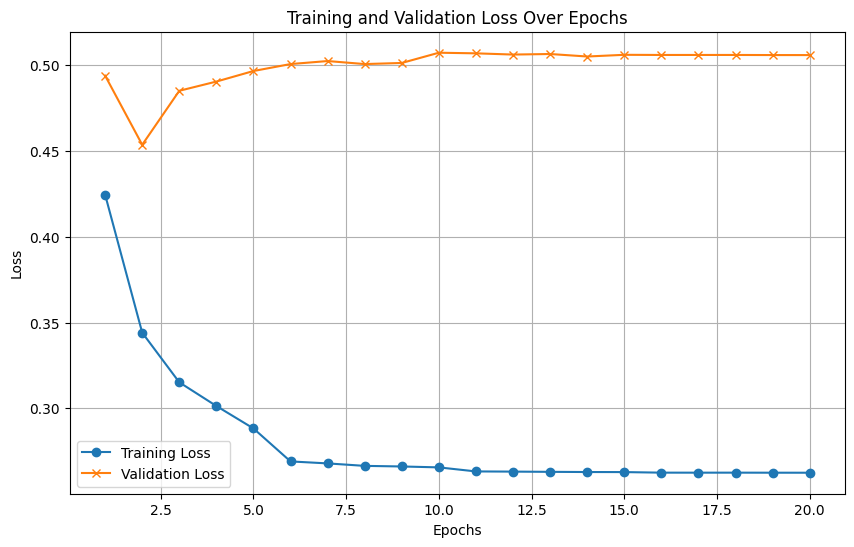

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label="Training Loss", marker='o')
plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss", marker='x')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
test_loss = 0.0
test_labels, test_predictions = [], []

model.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        images, labels = images.squeeze(1).to(device), labels.squeeze().to(device)
        output = model(images)
        loss = criterion(output, labels)
        test_loss += loss.item()
        test_labels.append(labels)
        test_predictions.append(output)

test_labels = torch.cat(test_labels)
test_predictions = torch.cat(test_predictions)

test_probs = torch.exp(test_predictions)

test_accuracy = accuracy_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy()
)
test_precision = precision_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), 
    average="weighted", zero_division=0
)
test_recall = recall_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), 
    average="weighted", zero_division=0
)
test_f1 = f1_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), 
    average="weighted", zero_division=0
)


print("\nFinal Test Evaluation:")
print(f"Test Loss: {test_loss / len(dataloader_test):.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")



Final Test Evaluation:
Test Loss: 0.4820
Test Accuracy: 0.8148
Test Precision: 0.7350
Test Recall: 0.8148
Test F1 Score: 0.7463


In [25]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{test_accuracy:.4f}"],
["Precisão (weighted)", f"{test_precision:.4f}"],
["Recall (weighted)", f"{test_recall:.4f}"],
["F1-score (weighted)", f"{test_f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │  0.8148 │
├─────────────────────┼─────────┤
│ Precisão (weighted) │  0.735  │
├─────────────────────┼─────────┤
│ Recall (weighted)   │  0.8148 │
├─────────────────────┼─────────┤
│ F1-score (weighted) │  0.7463 │
╘═════════════════════╧═════════╛


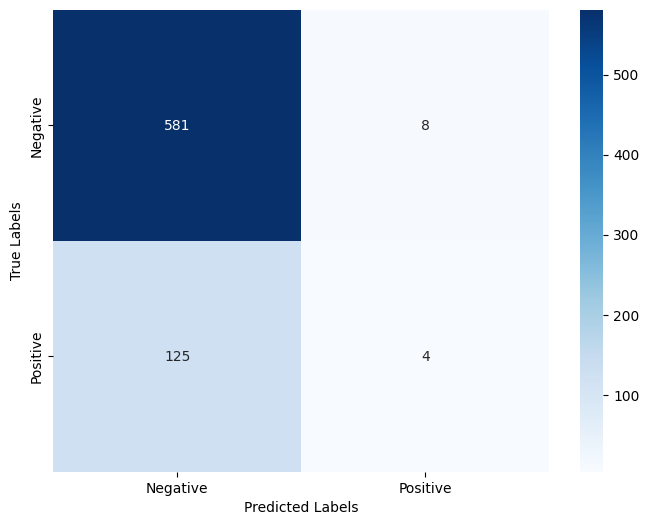

In [26]:
cm = confusion_matrix(test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), labels=[0, 1])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### Testando com Outros datasets

In [27]:
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")
shutil.copytree(path, "/content/", dirs_exist_ok=True)
!ls lung_colon_image_set

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
colon_image_sets  lung_image_sets


In [28]:
class LC25000Formatter:
    def __init__(self, input_path, output_csv):
        self.input_path = input_path
        self.output_csv_path = output_csv

    def run(self):
        df = self.process_directory(self.input_path)
        df.to_csv(self.output_csv_path, index=False)
        print(f"CSV salvo com sucesso em: {self.output_csv_path}")

    def process_directory(self, input_path: str):
        label_map = {
            "colon_n": int(0),
            "colon_aca": int(1)
        }
        image_extensions = ['.jpg', '.jpeg', '.png']
        image_paths = list(self.input_path.glob('**/*'))

        data = []
        for path in tqdm.tqdm(image_paths):
            if path.suffix.lower() in image_extensions and path.is_file():
                label = path.parent.name
                segmentation = path.parent.name
                data.append({
                    "path": str(path.resolve()),
                    "label": label_map[label],
                    "segmentation": segmentation
                })

        df = pd.DataFrame(data)
        return df

In [29]:
 
path_to_dataset_lc = pathlib.Path('/content/lung_colon_image_set/colon_image_sets')
LC25000Formatter(input_path = path_to_dataset_lc, output_csv = "nb_lc25000.csv").run()
dataframe_lc = pd.read_csv("/content/nb_lc25000.csv")
df_test_lc = dataframe_lc[["path", "label"]]
print(f"Number of images in test dataset lc25000: {len(df_test_lc)}")

100%|██████████| 10002/10002 [00:00<00:00, 26323.59it/s]


CSV salvo com sucesso em: nb_lc25000.csv
Number of images in test dataset lc25000: 10000


In [30]:
df_test_lc_split, _ =train_test_split(
    df_test_lc,
    test_size=0.9,
    random_state=42,
    stratify=df_test_lc["label"]
    )

In [31]:
print(f"Number of images after split in dataset lc25000: {len(df_test_lc_split)}")

Number of images after split in dataset lc25000: 1000


In [32]:
class LC25000DatasetMemory(Dataset):
    def __init__(self, dataframe, transforms=None, target_column="label"):
        self.dataframe = dataframe
        self.transforms = transforms
        self.target_column = target_column

        self.images = []
        self.labels = []

        for idx, row in dataframe.iterrows():
            image_path = row["path"]
            image = Image.open(image_path).convert("RGB")
            image_np = np.array(image)

            if self.transforms:
                transformed = self.transforms(image=image_np)
                image_tensor = transformed["image"]
            else:
                image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)  # fallback

            self.images.append(image_tensor)
            self.labels.append(row[target_column])

        self.images = torch.stack(self.images)
        self.labels = torch.tensor(self.labels)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]
    

class CustomDatasetConfig:
    VAL_SIZE = 0.2
    SEED = 0x40

    TEST_TRANSFORMS = A.Compose([
        A.Resize(28, 28),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

    TRAIN_TRANSFORMS = A.Compose([
        A.Resize(28, 28),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

In [33]:
dataset_test_lc = LC25000DatasetMemory(
        df_test_lc_split,
        transforms=CustomDatasetConfig.TEST_TRANSFORMS,
        target_column="label",
    )
dataloader_test_lc25000 = DataLoader(dataset_test_lc, batch_size= batch_size, pin_memory = True,shuffle= False)

In [34]:
test_loss = 0.0
test_labels, test_predictions = [], []

model.eval()
with torch.no_grad():
    for images, labels in dataloader_test_lc25000:
        images, labels = images.squeeze(1).to(device), labels.squeeze().to(device)
        output = model(images)
        loss = criterion(output, labels)
        test_loss += loss.item()
        test_labels.append(labels)
        test_predictions.append(output)

test_labels = torch.cat(test_labels)
test_predictions = torch.cat(test_predictions)

test_probs = torch.exp(test_predictions)

test_accuracy_lc25000 = accuracy_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy()
)
test_precision_lc25000 = precision_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), 
    average="weighted", zero_division=0
)
test_recall_lc25000 = recall_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), 
    average="weighted", zero_division=0
)
test_f1_lc25000 = f1_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), 
    average="weighted", zero_division=0
)


print("\nFinal Test Evaluation:")
print(f"Test Loss: {test_loss / len(dataloader_test_lc25000):.4f}")
print(f"Test Accuracy: {test_accuracy_lc25000:.4f}")
print(f"Test Precision: {test_precision_lc25000:.4f}")
print(f"Test Recall: {test_recall_lc25000:.4f}")
print(f"Test F1 Score: {test_f1_lc25000:.4f}")



Final Test Evaluation:
Test Loss: 1.2660
Test Accuracy: 0.5030
Test Precision: 0.6508
Test Recall: 0.5030
Test F1 Score: 0.3417


In [35]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{test_accuracy_lc25000:.4f}"],
["Precisão (weighted)", f"{test_precision_lc25000:.4f}"],
["Recall (weighted)", f"{test_recall_lc25000:.4f}"],
["F1-score (weighted)", f"{test_f1_lc25000:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │  0.503  │
├─────────────────────┼─────────┤
│ Precisão (weighted) │  0.6508 │
├─────────────────────┼─────────┤
│ Recall (weighted)   │  0.503  │
├─────────────────────┼─────────┤
│ F1-score (weighted) │  0.3417 │
╘═════════════════════╧═════════╛


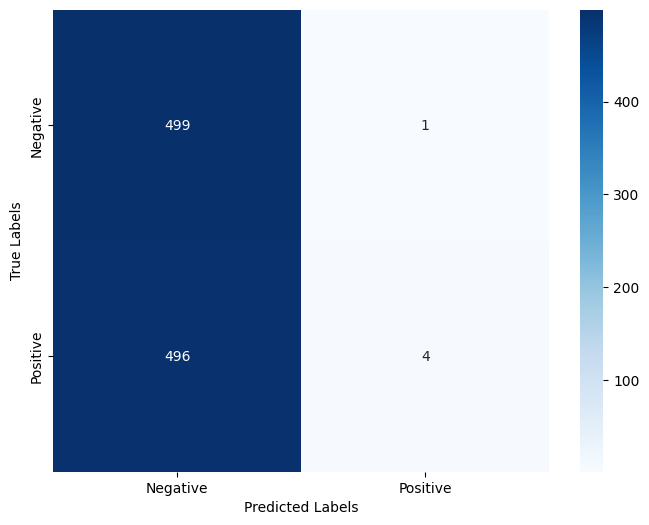

In [36]:
cm = confusion_matrix(test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), labels=[0, 1])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [37]:

path = kagglehub.dataset_download("kmader/colorectal-histology-mnist")
shutil.copytree(path, "/content/", dirs_exist_ok=True)
!ls Kather_texture_2016_image_tiles_5000/Kather_texture_2016_image_tiles_5000

Using Colab cache for faster access to the 'colorectal-histology-mnist' dataset.
01_TUMOR   03_COMPLEX  05_DEBRIS  07_ADIPOSE
02_STROMA  04_LYMPHO   06_MUCOSA  08_EMPTY


In [38]:
class CRC5000Formatter:
    def __init__(self, input_path, output_csv):
        self.input_path = input_path
        self.output_csv_path = output_csv

    def run(self):
        df = self.process_directory(self.input_path)
        df.to_csv(self.output_csv_path, index=False)
        print(f"CSV salvo com sucesso em: {self.output_csv_path}")

    def process_directory(self, input_path: str):
        label_map = {
            "01_TUMOR": int(1),
            "02_STROMA": int(0),
            "04_LYMPHO": int(0),
            "05_DEBRIS": int(0),
            "06_MUCOSA": int(0),
            "07_ADIPOSE": int(0),
            "08_EMPTY": int(0),
        }
        image_extensions = ['.tif', '.tiff']
        image_paths = list(self.input_path.glob('**/*'))

        data = []
        for path in tqdm.tqdm(image_paths):
            if path.suffix.lower() in image_extensions and path.is_file():
                label = path.parent.name
                if label not in label_map:
                    continue
                segmentation = path.parent.name
                data.append({
                    "path": str(path.resolve()),
                    "label": label_map[label],
                    "segmentation": segmentation
                })

        df = pd.DataFrame(data)
        return df

In [39]:
path_to_dataset_crc = pathlib.Path('/content/Kather_texture_2016_image_tiles_5000/Kather_texture_2016_image_tiles_5000')
CRC5000Formatter(input_path = path_to_dataset_crc, output_csv = "nb_crc5000.csv").run()
dataframe_crc = pd.read_csv("/content/nb_crc5000.csv")
df_test_crc = dataframe_crc[["path", "label"]]
print(f"Number of images in test dataset crc5000: {len(df_test_crc)}")

100%|██████████| 5008/5008 [00:00<00:00, 28076.10it/s]


CSV salvo com sucesso em: nb_crc5000.csv
Number of images in test dataset crc5000: 4375


In [40]:
df_test_crc_split, _ =train_test_split(
    df_test_crc,
    test_size=0.9,
    random_state=42,
    stratify=df_test_crc["label"]
    )

In [41]:
print(f"Number of images after split in dataset crc5000: {len(df_test_crc_split)}")

Number of images after split in dataset crc5000: 437


In [42]:
class CRC5000DatasetMemory(Dataset):
    def __init__(self, dataframe, transforms=None, target_column="label"):
        self.dataframe = dataframe
        self.transforms = transforms
        self.target_column = target_column

        self.images = []
        self.labels = []

        for idx, row in dataframe.iterrows():
            image_path = row["path"]
            image = Image.open(image_path).convert("RGB")
            image_np = np.array(image)

            if self.transforms:
                transformed = self.transforms(image=image_np)
                image_tensor = transformed["image"]
            else:
                image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)  # fallback

            self.images.append(image_tensor)
            self.labels.append(row[target_column])

        self.images = torch.stack(self.images)
        self.labels = torch.tensor(self.labels)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]
    

In [43]:
dataset_test_crc = CRC5000DatasetMemory(
        df_test_crc_split,
        transforms=CustomDatasetConfig.TEST_TRANSFORMS,
        target_column="label",
    )
dataloader_test_crc5000 = DataLoader(dataset_test_crc, batch_size= batch_size, pin_memory = True,shuffle= False)

In [44]:
test_loss = 0.0
test_labels, test_predictions = [], []

model.eval()
with torch.no_grad():
    for images, labels in dataloader_test_crc5000:
        images, labels = images.squeeze(1).to(device), labels.squeeze().to(device)
        output = model(images)
        loss = criterion(output, labels)
        test_loss += loss.item()
        test_labels.append(labels)
        test_predictions.append(output)

test_labels = torch.cat(test_labels)
test_predictions = torch.cat(test_predictions)

test_probs = torch.exp(test_predictions)

test_accuracy_crc5000 = accuracy_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy()
)
test_precision_crc5000 = precision_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), 
    average="weighted", zero_division=0
)
test_recall_crc5000 = recall_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), 
    average="weighted", zero_division=0
)
test_f1_crc5000 = f1_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), 
    average="weighted", zero_division=0
)


print("\nFinal Test Evaluation:")
print(f"Test Loss: {test_loss / len(dataloader_test_lc25000):.4f}")
print(f"Test Accuracy: {test_accuracy_crc5000:.4f}")
print(f"Test Precision: {test_precision_crc5000:.4f}")
print(f"Test Recall: {test_recall_crc5000:.4f}")
print(f"Test F1 Score: {test_f1_crc5000:.4f}")



Final Test Evaluation:
Test Loss: 0.1843
Test Accuracy: 0.8535
Test Precision: 0.7860
Test Recall: 0.8535
Test F1 Score: 0.7983


In [45]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{test_accuracy_crc5000:.4f}"],
["Precisão (weighted)", f"{test_precision_crc5000:.4f}"],
["Recall (weighted)", f"{test_recall_crc5000:.4f}"],
["F1-score (weighted)", f"{test_f1_crc5000:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │  0.8535 │
├─────────────────────┼─────────┤
│ Precisão (weighted) │  0.786  │
├─────────────────────┼─────────┤
│ Recall (weighted)   │  0.8535 │
├─────────────────────┼─────────┤
│ F1-score (weighted) │  0.7983 │
╘═════════════════════╧═════════╛


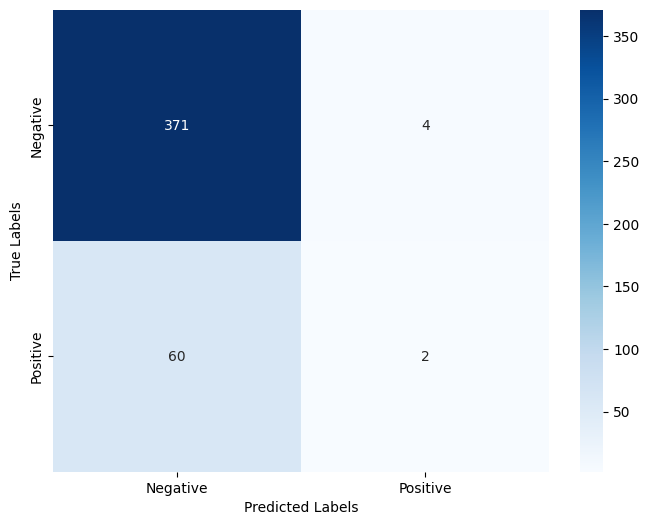

In [46]:
cm = confusion_matrix(test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), labels=[0, 1])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()